# Heart Disease Prediction using Machine Learning

## Project Overview
The goal of this project is to build a **Machine Learning model** that can predict whether a person is likely to have **heart disease** based on various clinical and diagnostic features.

These features may include:
- Age
- Sex
- Chest pain type
- Resting blood pressure
- Cholesterol level
- Fasting blood sugar
- ECG results
- Exercise-induced angina
- Other health indicators

The model will analyze these features to determine the likelihood of heart disease in a patient.

---

## Problem Type
This is a **Binary Classification Problem** because the target variable **HeartDisease** has two possible outcomes:

- **0 → No heart disease**
- **1 → Heart disease present**

The model will learn patterns from patient data and classify whether a person is likely to have heart disease.

---

## Steps in this Notebook

In this notebook, we will perform the following steps:

1. **Load and inspect the dataset**
2. **Perform Exploratory Data Analysis (EDA)**
3. **Preprocess categorical and numerical features**
4. **Train a baseline classification model**
5. **Evaluate the model using classification metrics**
6. **Interpret the results**

---

## Project Objective
The purpose of this project is not only to build a predictive model but also to **understand which patient features are most related to heart disease prediction**.

By analyzing feature importance and model performance, we aim to gain insights that could support **data-driven healthcare decision-making**.

In [11]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download and load dataset
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
csv_path = os.path.join(path, "heart.csv")
df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [12]:
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


Column names:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Data types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


# Exploratory Data Analysis (EDA)

## Exploratory Data Analysis helps us understand the dataset before building a machine learning model.
In this section we will examine:

1. **the distribution of the target variable**
2. **distributions of numerical features**
3. **relationships between features and the target**
4. **correlations between variables**

This helps us detect patterns, class imbalance, and potential issues such as outliers.

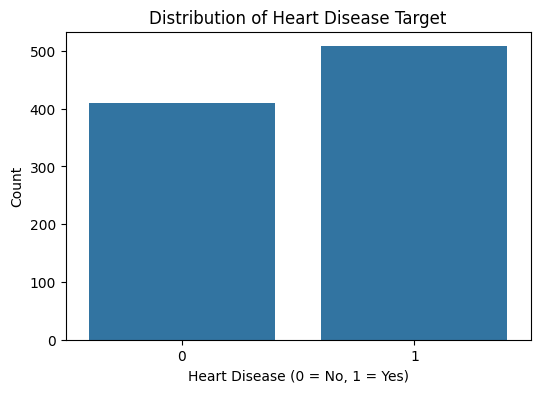

HeartDisease
1    508
0    410
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="HeartDisease", data=df)
plt.title("Distribution of Heart Disease Target")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

print(df["HeartDisease"].value_counts())

### this dataset contains both people with the heart disease and without heart disease 

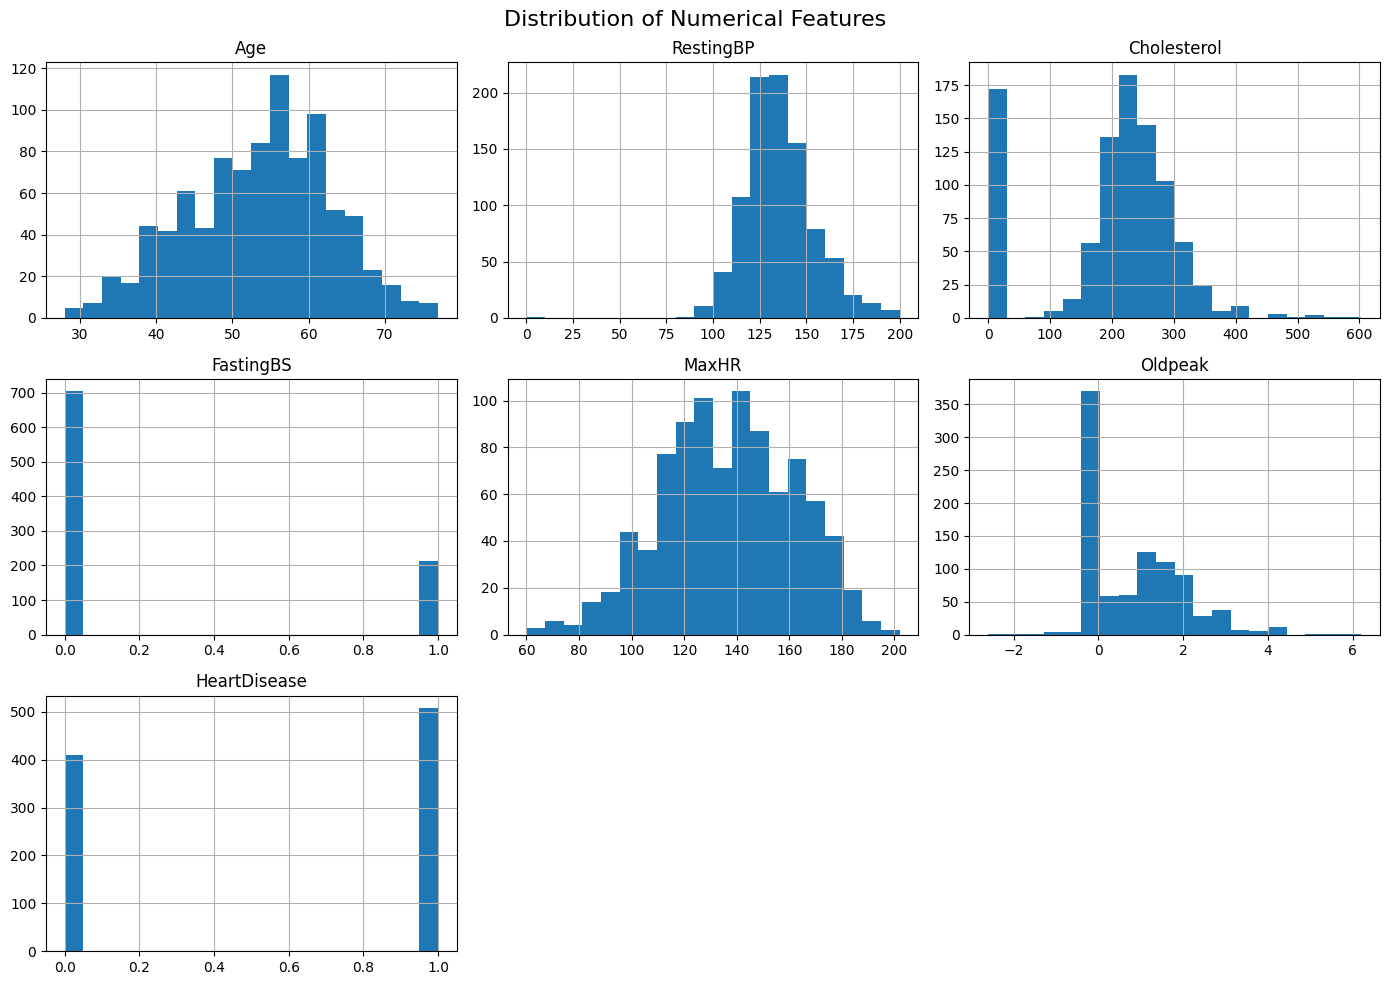

In [14]:
df.hist(figsize=(14,10), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## Observation

#### From the histograms we can observe how each numerical variable is distributed.
#### Some variables appear approximately normally distributed while others show skewness.
#### Understanding these distributions is helpful for preprocessing and modeling decisions.

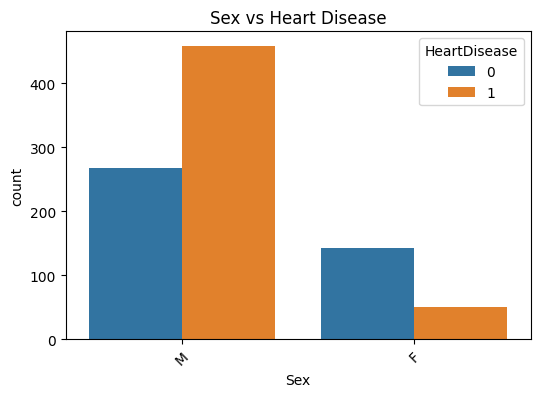

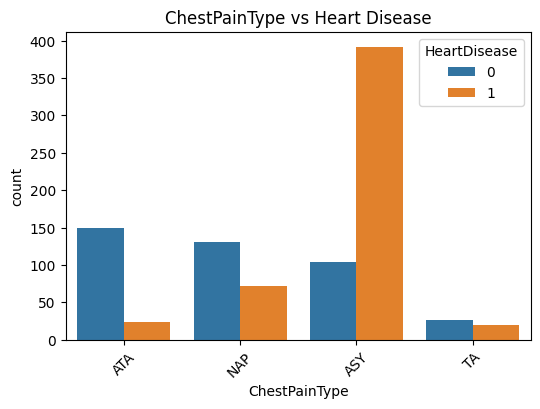

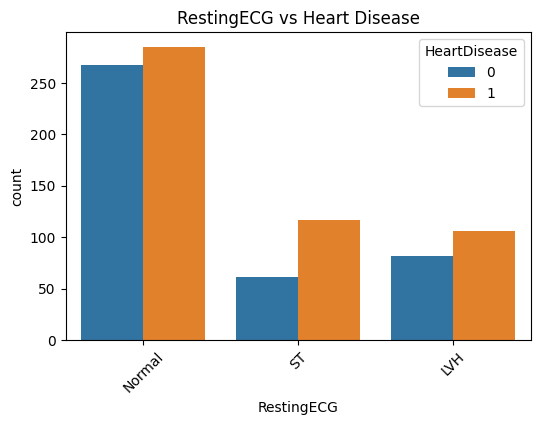

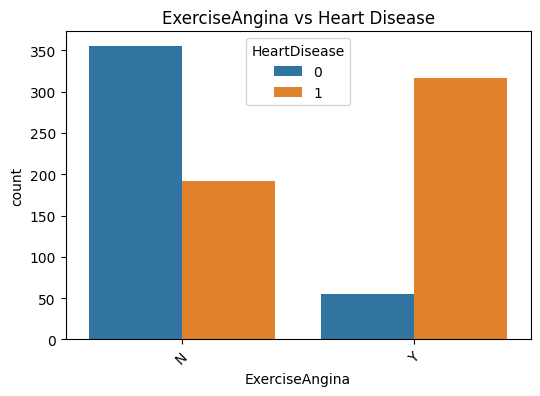

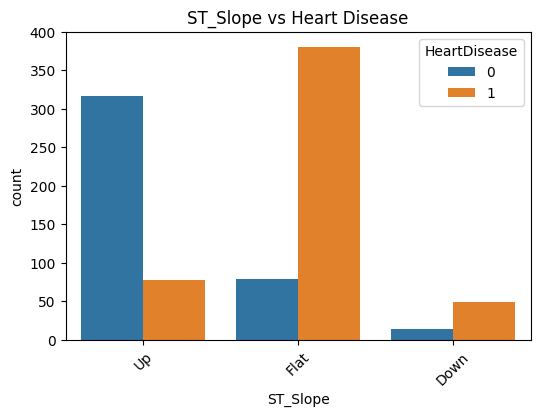

In [15]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="HeartDisease", data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.xticks(rotation=45)
    plt.show()

## Data Preprocessing

### Machine learning models require numerical input features.
Since this dataset contains several categorical variables, we need to convert them into numerical form before training a model.
## In this section we will:
1. **encode binary categorical variables**
2. **apply one-hot encoding to multi-category variables**
3. **prepare the final dataset for modeling**

In [16]:
categorical_columns = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [17]:
df_encoded = df.copy()
df_encoded["Sex"] = df_encoded["Sex"].map({"F": 0, "M": 1}) # 0 for the female and 1 for male 
df_encoded["ExerciseAngina"] = df_encoded["ExerciseAngina"].map({"N": 0, "Y": 1}) # 0 for NO and 1 for YES

### now we have some columns that need the one-hot encoding lets do that 

In [18]:
df_encoded = pd.get_dummies(df_encoded, columns=["RestingECG"], drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns=["ChestPainType"],drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns=["ST_Slope"],drop_first=True)
# many times the encoded values get converted to the boolean values lets convert them to the integer 

In [22]:
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print("Encoded dataset shape:", df_encoded.shape)

display(df_encoded.head())

print("\nData types after encoding:")
print(df_encoded.dtypes)

Encoded dataset shape: (918, 16)


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,RestingECG_Normal,RestingECG_ST,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,1,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,1,0,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,1,0,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,1,0,0,1,0,0,1



Data types after encoding:
Age                    int64
Sex                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
RestingECG_Normal      int64
RestingECG_ST          int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
ST_Slope_Flat          int64
ST_Slope_Up            int64
dtype: object


## Correlation Analysis

The correlation heatmap shows the relationships between variables in the dataset.
This visualization helps identify potentially important predictors of heart disease as well as relationships between features.

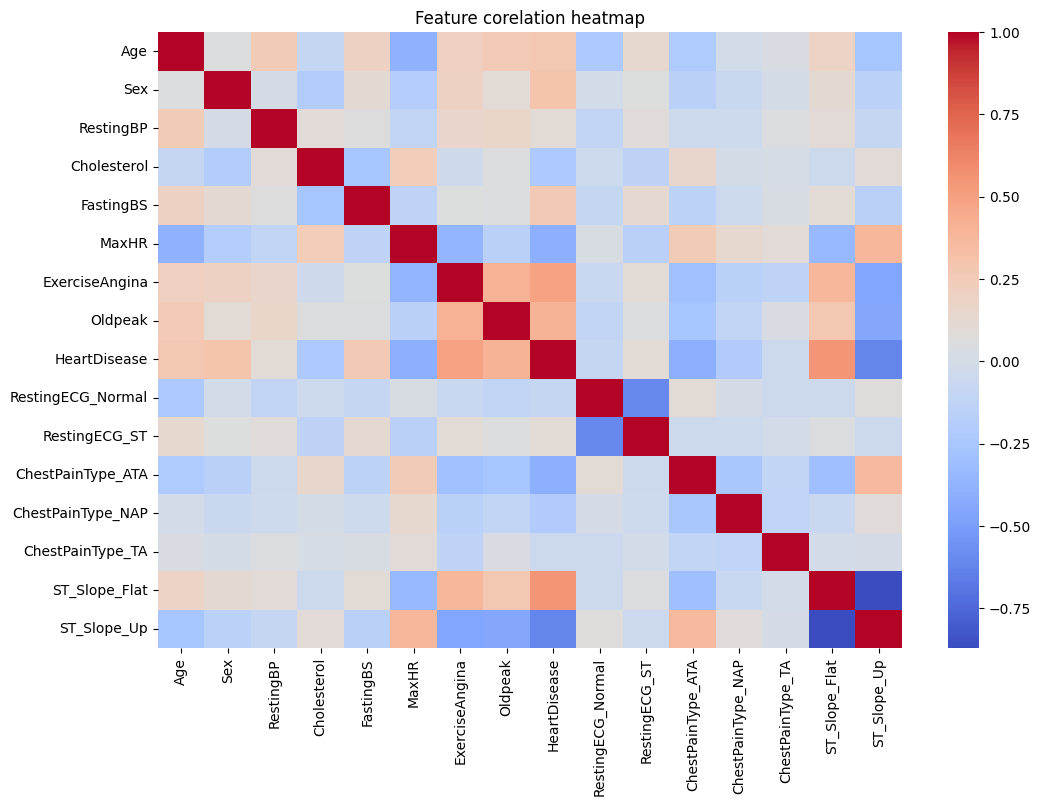

In [24]:
# corelation analysis is very important in the EDA 
plt.figure(figsize= (12,8))
sns.heatmap(df_encoded.corr(),cmap = "coolwarm",annot = False)
plt.title("Feature corelation heatmap")
plt.show()

In [27]:
X = df_encoded.drop("HeartDisease",axis =1) # axis 1 denotes the column 
y = df_encoded["HeartDisease"] 
# we got our targets and feature 
print("Shape of the X is ", X.shape)
print("Shape of the Y is ", y.shape)

Shape of the X is  (918, 15)
Shape of the Y is  (918,)


**look at the above output we have 15 features in total excluding the our target it is of dimension 918(rows) x 15(colums)** 

## Train–Test Split
## To evaluate the performance of our machine learning model, we divide the dataset into:
1. **Training set – used to train the model**
2. **Testing set – used to evaluate the model on unseen data**

In [29]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
# 20% of data is now test data and 80 percent of the data is train data on which model will run

Training data shape: (734, 15)
Testing data shape: (184, 15)


## Feature Scaling
**Many machine learning algorithms perform better when numerical features are scaled to a similar range.**

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline Model: Logistic Regression

### Logistic Regression is a widely used algorithm for binary classification problems.
### It estimates the probability that a given input belongs to a particular class.


In [32]:
from sklearn.linear_model import LogisticRegression 
model = LogisticRegression(max_iter = 750)
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,750
,multi_class,'deprecated'


In [35]:
y_pred = model.predict(X_test_scaled)

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8532608695652174


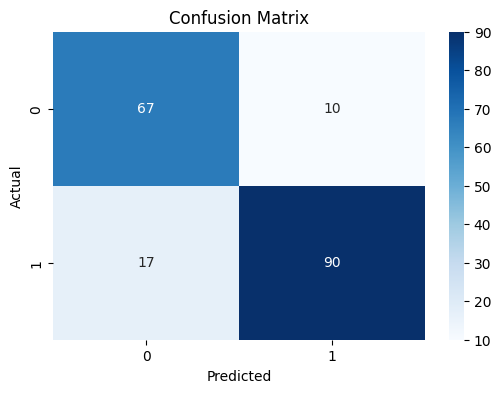

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Performance Interpretation

**The logistic regression model provides a baseline for heart disease prediction.
The evaluation metrics show how well the model identifies patients with and without heart disease.
Precision and recall are particularly important in medical prediction tasks because false negatives and false positives can have different implications.
Further improvements can be explored using more advanced machine learning algorithms.**

## Model Comparison
## In addition to Logistic Regression, we will evaluate two additional machine learning models:
1. **Random Forest Classifier – an ensemble model based on decision trees**
2. **Support Vector Machine (SVM) – a powerful classifier that finds optimal decision boundaries**

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [42]:
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)

In [43]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8695652173913043

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



## Support Vector Machine (SVM)
**Support Vector Machines classify data by finding the optimal hyperplane that separates different classes.**

In [44]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled,y_train)
svm_pred = svm_model.predict(X_test_scaled)

In [45]:
svm_accuracy = accuracy_score(y_test,svm_pred)
print("SVM model accuracy:", svm_accuracy)

SVM model accuracy: 0.875


In [46]:
model_result = pd.DataFrame({"Model":["LogisticRegression" ,"RandomForestClassifier" ,"SupportVectorMachines"],
                            "Accuracies":[accuracy, rf_accuracy, svm_accuracy]})
print(model_result)

                    Model  Accuracies
0      LogisticRegression    0.853261
1  RandomForestClassifier    0.869565
2   SupportVectorMachines    0.875000


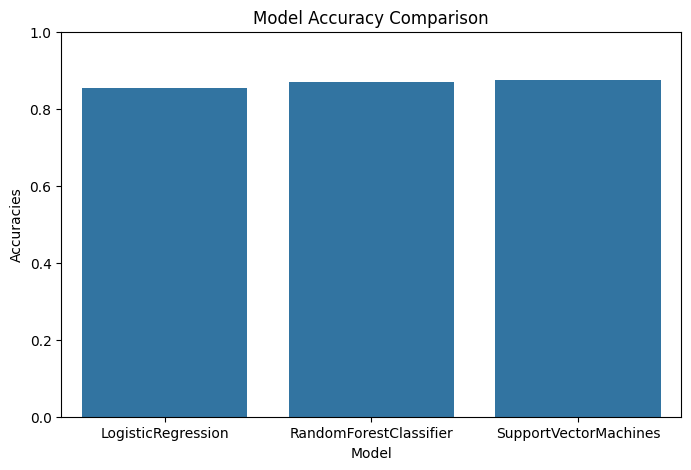

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracies", data=model_result)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

## Model Comparison Results

**The three models were evaluated using accuracy and classification metrics.**
1. **Logistic Regression provides a strong baseline model.**
2. **Random Forest captures more complex relationships through ensemble learning.**
3. **Support Vector Machine finds optimal decision boundaries in feature space.**
***By comparing these models, we can determine which algorithm performs best for predicting heart disease on this dataset.***